In [1]:
import pandas as pd

# Load CO2 hourly dataset
co2 = pd.read_csv("co2_dk1_hourly_2022_2024.csv")

# Convert timestamp to datetime with UTC timezone
co2["datetime_utc"] = pd.to_datetime(co2["datetime_utc"], utc=True)

# Basic checks
print("Shape:", co2.shape)
print("\nColumns:")
print(co2.columns.tolist())

print("\nDtypes:")
print(co2.dtypes)

print("\nFirst 5 rows:")
display(co2.head())

Shape: (26304, 3)

Columns:
['datetime_utc', 'co2_intensity', 'PriceArea']

Dtypes:
datetime_utc     datetime64[us, UTC]
co2_intensity                float64
PriceArea                        str
dtype: object

First 5 rows:


,datetime_utc,co2_intensity,PriceArea
0,2022-01-01 00:00:00+00:00,63.000000,DK1
1,2022-01-01 01:00:00+00:00,68.750000,DK1
2,2022-01-01 02:00:00+00:00,72.583333,DK1
3,2022-01-01 03:00:00+00:00,77.250000,DK1
4,2022-01-01 04:00:00+00:00,79.750000,DK1


Datasets were merged sequentially to ensure consistency and alignment. First, the settlement (production and consumption) dataset was merged with the CO₂ intensity data. The resulting dataset was then combined with the weather data. This stepwise approach ensures a clean merge, as all datasets share a common `datetime_utc` timestamp.

In [2]:
# Load processed settlement dataset
pcs = pd.read_csv("pcs_processed_dk1_utc.csv")

# Convert timestamp to datetime with UTC timezone
pcs["datetime_utc"] = pd.to_datetime(pcs["datetime_utc"], utc=True)

# Basic checks
print("Shape:", pcs.shape)
print("\nFirst 10 columns:")
print(pcs.columns.tolist()[:10])

print("\nDtypes of key columns:")
print(pcs[["datetime_utc", "GrossConsumptionMWh", "TotalProduction_MWh"]].dtypes)

print("\nFirst 5 rows:")
display(pcs.head())

Shape: (26304, 36)

First 10 columns:
['datetime_utc', 'CentralPowerMWh', 'LocalPowerMWh', 'CommercialPowerMWh', 'LocalPowerSelfConMWh', 'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh', 'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh', 'HydroPowerMWh']

Dtypes of key columns:
datetime_utc           datetime64[us, UTC]
GrossConsumptionMWh                float64
TotalProduction_MWh                float64
dtype: object

First 5 rows:


,datetime_utc,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,...,WindOffshore_MWh,WindOnshore_MWh,TotalWind_MWh,TotalSolar_MWh,TotalRenewables_MWh,TotalConventional_MWh,NetExchange_MWh,TotalImports_MWh,TotalExports_MWh,TotalProduction_MWh
0,2022-01-01 00:00:00+00:00,293.093959,156.007948,85.381966,16.197998,138.357348,899.588499,6.556590,995.135115,1.641966,...,1037.945847,1001.691705,2039.637552,0.021625,2041.301143,550.681871,-385.7727,1330.253,1716.0257,2591.983014
1,2022-01-01 01:00:00+00:00,384.846011,152.127928,86.865465,15.207601,119.702698,921.140135,5.398335,893.822227,1.637933,...,1040.842833,899.220562,1940.063395,0.022582,1941.723910,639.047005,-433.0126,1253.937,1686.9496,2580.770915
2,2022-01-01 02:00:00+00:00,365.706619,154.854604,86.807320,15.404626,119.564946,835.099673,4.786685,787.981293,1.639639,...,954.664619,792.767978,1747.432597,0.019940,1749.092176,622.773169,-348.4763,1021.750,1370.2263,2371.865345
3,2022-01-01 03:00:00+00:00,379.162111,154.907694,86.882696,15.542090,125.643131,678.922773,2.741542,781.776899,1.634412,...,804.565904,784.518441,1589.084345,0.022718,1590.741475,636.494591,-177.0123,955.643,1132.6553,2227.236066
4,2022-01-01 04:00:00+00:00,370.112134,156.512416,87.018405,14.962279,157.398152,736.866967,2.252833,614.282126,1.630415,...,894.265119,616.534959,1510.800078,0.021027,1512.451520,628.605234,-75.2910,1057.204,1132.4950,2141.056754


In [3]:
# Merge processed settlement dataset with CO2 dataset
merge_sc = pd.merge(
    pcs,
    co2[["datetime_utc", "co2_intensity"]],
    on="datetime_utc",
    how="inner"
)

# Basic checks after merge
print("Merged shape:", merge_sc.shape)
print("\nNew columns added:")
print([col for col in merge_sc.columns if col == "co2_intensity"])

print("\nMissing values after merge:")
print(merge_sc[["datetime_utc", "co2_intensity"]].isnull().sum())

print("\nFirst 5 rows of merged dataset:")
display(merge_sc[["datetime_utc", "GrossConsumptionMWh", "co2_intensity"]].head())

Merged shape: (26304, 37)

New columns added:
['co2_intensity']

Missing values after merge:
datetime_utc     0
co2_intensity    0
dtype: int64

First 5 rows of merged dataset:


,datetime_utc,GrossConsumptionMWh,co2_intensity
0,2022-01-01 00:00:00+00:00,2206.210314,63.000000
1,2022-01-01 01:00:00+00:00,2147.758315,68.750000
2,2022-01-01 02:00:00+00:00,2023.389045,72.583333
3,2022-01-01 03:00:00+00:00,2050.223766,77.250000
4,2022-01-01 04:00:00+00:00,2065.765754,79.750000


The processed electricity dataset was merged with the CO₂ intensity dataset using the common timestamp variable (datetime_utc). An inner join was applied to retain only observations with matching timestamps in both datasets. This ensured temporal alignment between electricity system variables and CO₂ intensity values.

In [4]:
# Now Load weather hourly dataset
weather = pd.read_csv("weather_dk1_hourly_2022_2024.csv")

# Convert timestamp to datetime with UTC timezone
weather["datetime_utc"] = pd.to_datetime(weather["datetime_utc"], utc=True)

# Basic checks
print("Shape:", weather.shape)
print("\nColumns:")
print(weather.columns.tolist())

print("\nDtypes:")
print(weather.dtypes)

print("\nFirst 5 rows:")
display(weather.head())

Shape: (26304, 4)

Columns:
['datetime_utc', 'temperature', 'wind_speed', 'solar_radiation']

Dtypes:
datetime_utc       datetime64[us, UTC]
temperature                    float64
wind_speed                     float64
solar_radiation                float64
dtype: object

First 5 rows:


,datetime_utc,temperature,wind_speed,solar_radiation
0,2022-01-01 00:00:00+00:00,6.616667,3.566667,1.0
1,2022-01-01 01:00:00+00:00,6.266667,3.200000,1.0
2,2022-01-01 02:00:00+00:00,6.150000,2.750000,1.0
3,2022-01-01 03:00:00+00:00,6.016667,2.633333,1.0
4,2022-01-01 04:00:00+00:00,6.150000,2.050000,1.0


In [5]:
# Merge weather dataset into the current merged dataset
final_df = pd.merge(
    merge_sc,
    weather,
    on="datetime_utc",
    how="inner"
)

# Basic checks
print("Final merged shape:", final_df.shape)

print("\nNew weather columns added:")
print([col for col in ["temperature", "wind_speed", "solar_radiation"] if col in final_df.columns])

print("\nMissing values in key columns after merge:")
print(final_df[["datetime_utc", "GrossConsumptionMWh", "co2_intensity", "temperature", "wind_speed", "solar_radiation"]].isnull().sum())

print("\nFirst 5 rows of final dataset:")
display(final_df[[
    "datetime_utc",
    "GrossConsumptionMWh",
    "co2_intensity",
    "temperature",
    "wind_speed",
    "solar_radiation"
]].head())

Final merged shape: (26304, 40)

New weather columns added:
['temperature', 'wind_speed', 'solar_radiation']

Missing values in key columns after merge:
datetime_utc           0
GrossConsumptionMWh    0
co2_intensity          0
temperature            0
wind_speed             0
solar_radiation        0
dtype: int64

First 5 rows of final dataset:


,datetime_utc,GrossConsumptionMWh,co2_intensity,temperature,wind_speed,solar_radiation
0,2022-01-01 00:00:00+00:00,2206.210314,63.000000,6.616667,3.566667,1.0
1,2022-01-01 01:00:00+00:00,2147.758315,68.750000,6.266667,3.200000,1.0
2,2022-01-01 02:00:00+00:00,2023.389045,72.583333,6.150000,2.750000,1.0
3,2022-01-01 03:00:00+00:00,2050.223766,77.250000,6.016667,2.633333,1.0
4,2022-01-01 04:00:00+00:00,2065.765754,79.750000,6.150000,2.050000,1.0


In [6]:
# Save final merged dataset
final_df.to_csv("final_thesis_dataset.csv", index=False)
final_df.to_pickle("final_thesis_dataset.pkl")

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [7]:
#First Post-Merge EDA
print(final_df.shape)
print("\nColumns:")
print(final_df.columns.tolist())

(26304, 40)

Columns:
['datetime_utc', 'CentralPowerMWh', 'LocalPowerMWh', 'CommercialPowerMWh', 'LocalPowerSelfConMWh', 'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh', 'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh', 'HydroPowerMWh', 'SolarPowerLt10kW_MWh', 'SolarPowerGe10Lt40kW_MWh', 'SolarPowerGe40kW_MWh', 'SolarPowerSelfConMWh', 'UnknownProdMWh', 'ExchangeNO_MWh', 'ExchangeSE_MWh', 'ExchangeGE_MWh', 'ExchangeNL_MWh', 'ExchangeGB_MWh', 'ExchangeGreatBelt_MWh', 'GrossConsumptionMWh', 'GridLossTransmissionMWh', 'GridLossInterconnectorsMWh', 'GridLossDistributionMWh', 'PowerToHeatMWh', 'WindOffshore_MWh', 'WindOnshore_MWh', 'TotalWind_MWh', 'TotalSolar_MWh', 'TotalRenewables_MWh', 'TotalConventional_MWh', 'NetExchange_MWh', 'TotalImports_MWh', 'TotalExports_MWh', 'TotalProduction_MWh', 'co2_intensity', 'temperature', 'wind_speed', 'solar_radiation']


In [8]:
#Summary statistics
final_df[[
    "co2_intensity",
    "GrossConsumptionMWh",
    "TotalProduction_MWh",
    "temperature",
    "wind_speed",
    "solar_radiation"
]].describe()

,co2_intensity,GrossConsumptionMWh,TotalProduction_MWh,temperature,wind_speed,solar_radiation
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,114.783189,2631.678200,2689.853546,9.164613,3.225533,117.145859
std,70.820041,501.507219,1195.985701,6.478644,1.975884,189.650940
min,9.000000,1466.739560,244.265033,-13.783333,0.000000,0.000000
25%,56.833333,2247.613476,1738.729814,4.328776,1.716667,0.000000
50%,101.583333,2645.197192,2590.160062,8.950000,2.950000,8.333333
75%,161.250000,2991.146360,3564.525410,13.983333,4.383333,161.500000
max,464.750000,4228.427907,6658.678942,29.783333,16.883333,922.166667


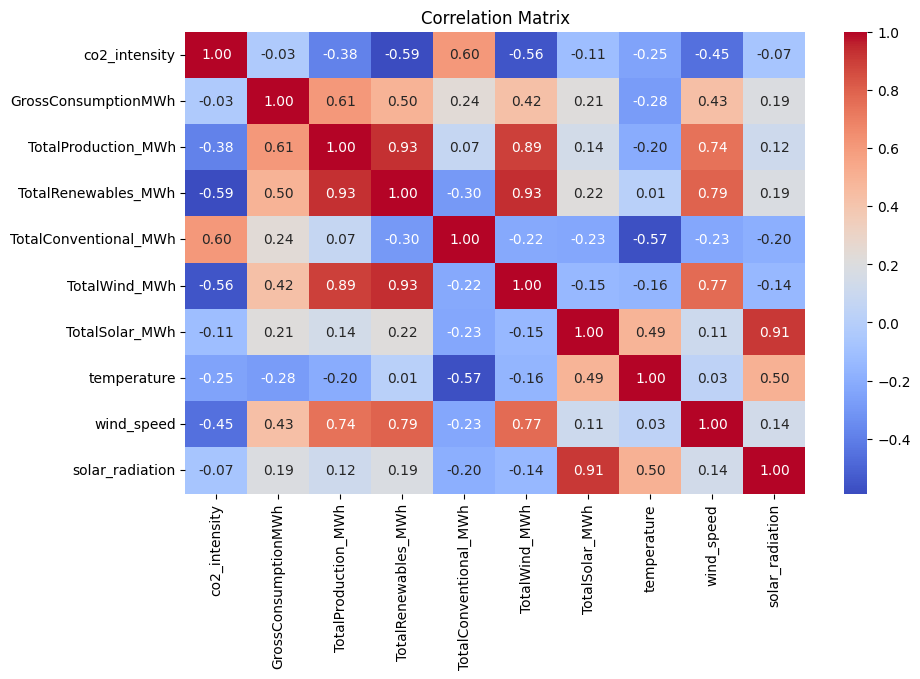

In [9]:
#Correlation analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Select key variables
corr_cols = [
    "co2_intensity",
    "GrossConsumptionMWh",
    "TotalProduction_MWh",
    "TotalRenewables_MWh",
    "TotalConventional_MWh",
    "TotalWind_MWh",
    "TotalSolar_MWh",
    "temperature",
    "wind_speed",
    "solar_radiation"
]

corr_matrix = final_df[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation analysis suggests that CO₂ intensity in DK1 is negatively associated with renewable generation, particularly wind-related variables. Total renewable generation and total wind generation show moderate to strong negative correlations with CO₂ intensity, indicating that hours with higher renewable generation tend to coincide with lower carbon intensity.

Gross electricity consumption shows only a weak direct linear relationship with CO₂ intensity, suggesting that demand alone does not explain much of the variation in carbon intensity. However, these correlations should be interpreted as exploratory associations rather than causal effects.

Several production-related variables are also highly correlated with each other, indicating potential multicollinearity. This is particularly relevant for linear regression models and motivates careful feature selection and interpretation.

In [10]:
# Convert UTC to Danish local time
final_df["datetime_dk"] = final_df["datetime_utc"].dt.tz_convert("Europe/Copenhagen")
display(final_df.head())

,datetime_utc,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,...,TotalConventional_MWh,NetExchange_MWh,TotalImports_MWh,TotalExports_MWh,TotalProduction_MWh,co2_intensity,temperature,wind_speed,solar_radiation,datetime_dk
0,2022-01-01 00:00:00+00:00,293.093959,156.007948,85.381966,16.197998,138.357348,899.588499,6.556590,995.135115,1.641966,...,550.681871,-385.7727,1330.253,1716.0257,2591.983014,63.000000,6.616667,3.566667,1.0,2022-01-01 01:00:00+01:00
1,2022-01-01 01:00:00+00:00,384.846011,152.127928,86.865465,15.207601,119.702698,921.140135,5.398335,893.822227,1.637933,...,639.047005,-433.0126,1253.937,1686.9496,2580.770915,68.750000,6.266667,3.200000,1.0,2022-01-01 02:00:00+01:00
2,2022-01-01 02:00:00+00:00,365.706619,154.854604,86.807320,15.404626,119.564946,835.099673,4.786685,787.981293,1.639639,...,622.773169,-348.4763,1021.750,1370.2263,2371.865345,72.583333,6.150000,2.750000,1.0,2022-01-01 03:00:00+01:00
3,2022-01-01 03:00:00+00:00,379.162111,154.907694,86.882696,15.542090,125.643131,678.922773,2.741542,781.776899,1.634412,...,636.494591,-177.0123,955.643,1132.6553,2227.236066,77.250000,6.016667,2.633333,1.0,2022-01-01 04:00:00+01:00
4,2022-01-01 04:00:00+00:00,370.112134,156.512416,87.018405,14.962279,157.398152,736.866967,2.252833,614.282126,1.630415,...,628.605234,-75.2910,1057.204,1132.4950,2141.056754,79.750000,6.150000,2.050000,1.0,2022-01-01 05:00:00+01:00


The dataset timestamps are maintained in Coordinated Universal Time (UTC) to ensure a continuous and consistent temporal structure without missing or duplicated observations. For feature engineering, timestamps were converted to Danish local time (Europe/Copenhagen) to capture human activity patterns such as daily and weekly cycles.

Daylight Saving Time (DST) transitions introduce repeated or missing hours in local time; however, this does not affect the integrity of the dataset since the underlying UTC timestamps remain continuous. Time-based features were derived from local time to better reflect real-world electricity demand behavior.


In [11]:
# Create time-based features from Danish local time
final_df["hour"] = final_df["datetime_dk"].dt.hour
final_df["day_of_week"] = final_df["datetime_dk"].dt.dayofweek
final_df["month"] = final_df["datetime_dk"].dt.month
final_df["is_weekend"] = final_df["day_of_week"].isin([5, 6]).astype(int)

# Optional season feature
def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

final_df["season"] = final_df["month"].apply(month_to_season)

# Check result
display(final_df[[
    "datetime_utc", "datetime_dk", "hour", "day_of_week", "month", "is_weekend", "season"
]].head(10))

,datetime_utc,datetime_dk,hour,day_of_week,month,is_weekend,season
0,2022-01-01 00:00:00+00:00,2022-01-01 01:00:00+01:00,1,5,1,1,winter
1,2022-01-01 01:00:00+00:00,2022-01-01 02:00:00+01:00,2,5,1,1,winter
2,2022-01-01 02:00:00+00:00,2022-01-01 03:00:00+01:00,3,5,1,1,winter
3,2022-01-01 03:00:00+00:00,2022-01-01 04:00:00+01:00,4,5,1,1,winter
4,2022-01-01 04:00:00+00:00,2022-01-01 05:00:00+01:00,5,5,1,1,winter
5,2022-01-01 05:00:00+00:00,2022-01-01 06:00:00+01:00,6,5,1,1,winter
6,2022-01-01 06:00:00+00:00,2022-01-01 07:00:00+01:00,7,5,1,1,winter
7,2022-01-01 07:00:00+00:00,2022-01-01 08:00:00+01:00,8,5,1,1,winter
8,2022-01-01 08:00:00+00:00,2022-01-01 09:00:00+01:00,9,5,1,1,winter
9,2022-01-01 09:00:00+00:00,2022-01-01 10:00:00+01:00,10,5,1,1,winter


Time-based features such as hour of day, day of week, month, weekend indicator, and season were extracted from the Danish local timestamp. These features capture temporal patterns in electricity demand and CO₂ intensity.

In [12]:
pd.get_dummies(final_df["season"])

,autumn,spring,summer,winter
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True
...,...,...,...,...
26299,False,False,False,True
26300,False,False,False,True
26301,False,False,False,True
26302,False,False,False,True


In [13]:
final_df = pd.get_dummies(final_df, columns=["season"], drop_first=True, dtype=int)

In [14]:
final_df

,datetime_utc,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,...,wind_speed,solar_radiation,datetime_dk,hour,day_of_week,month,is_weekend,season_spring,season_summer,season_winter
0,2022-01-01 00:00:00+00:00,293.093959,156.007948,85.381966,16.197998,138.357348,899.588499,6.556590,995.135115,1.641966,...,3.566667,1.0,2022-01-01 01:00:00+01:00,1,5,1,1,0,0,1
1,2022-01-01 01:00:00+00:00,384.846011,152.127928,86.865465,15.207601,119.702698,921.140135,5.398335,893.822227,1.637933,...,3.200000,1.0,2022-01-01 02:00:00+01:00,2,5,1,1,0,0,1
2,2022-01-01 02:00:00+00:00,365.706619,154.854604,86.807320,15.404626,119.564946,835.099673,4.786685,787.981293,1.639639,...,2.750000,1.0,2022-01-01 03:00:00+01:00,3,5,1,1,0,0,1
3,2022-01-01 03:00:00+00:00,379.162111,154.907694,86.882696,15.542090,125.643131,678.922773,2.741542,781.776899,1.634412,...,2.633333,1.0,2022-01-01 04:00:00+01:00,4,5,1,1,0,0,1
4,2022-01-01 04:00:00+00:00,370.112134,156.512416,87.018405,14.962279,157.398152,736.866967,2.252833,614.282126,1.630415,...,2.050000,1.0,2022-01-01 05:00:00+01:00,5,5,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2024-12-31 19:00:00+00:00,179.777632,104.864880,47.265005,63.585440,223.355582,1294.122271,14.124422,3226.764954,2.771100,...,6.666667,0.0,2024-12-31 20:00:00+01:00,20,1,12,0,0,0,1
26300,2024-12-31 20:00:00+00:00,138.667766,98.445266,44.141762,66.598761,223.492111,1294.487429,14.271321,3373.379070,2.764208,...,7.033333,0.0,2024-12-31 21:00:00+01:00,21,1,12,0,0,0,1
26301,2024-12-31 21:00:00+00:00,140.647608,94.970844,43.635940,63.603273,223.491979,1291.828649,14.331433,3352.741712,2.867471,...,6.783333,0.0,2024-12-31 22:00:00+01:00,22,1,12,0,0,0,1
26302,2024-12-31 22:00:00+00:00,59.983576,96.811253,44.034018,72.715169,223.123877,1284.895609,14.273949,3234.240968,2.893669,...,6.375000,0.0,2024-12-31 23:00:00+01:00,23,1,12,0,0,0,1


The categorical variable “season” was one-hot encoded and converted into binary (0/1) variables. One category was dropped to avoid multicollinearity and serve as a reference baseline.

For linear regression, one category was dropped (drop first=true-code) to avoid multicollinearity and provide a reference baseline. Although tree-based models such as XGBoost are not affected by multicollinearity, the same encoding was retained to ensure consistency and improve interpretability of feature effects.

<Figure size 1200x500 with 0 Axes>

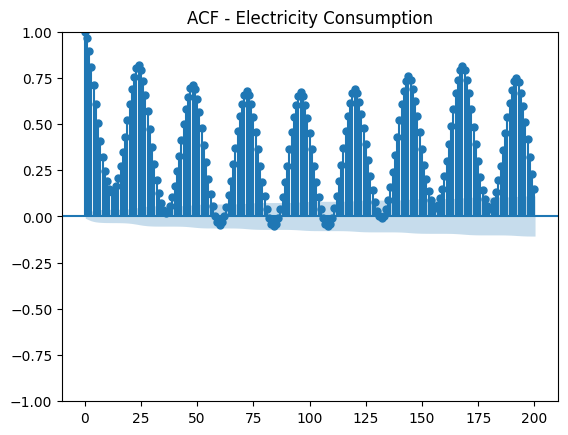

<Figure size 1200x500 with 0 Axes>

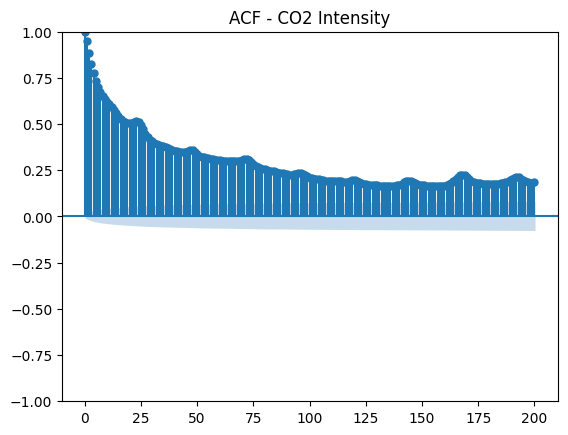

In [15]:
# Autocorrelation Analysis (ACF)

from statsmodels.graphics.tsaplots import plot_acf

#  ACF for Electricity Consumption 
plt.figure(figsize=(12,5))
plot_acf(final_df['GrossConsumptionMWh'], lags=200)
plt.title('ACF - Electricity Consumption')
plt.show()

#  ACF for CO2 Intensity 
plt.figure(figsize=(12,5))
plot_acf(final_df['co2_intensity'], lags=200)
plt.title('ACF - CO2 Intensity')
plt.show()

In [16]:
from statsmodels.tsa.stattools import acf

# Compute ACF values
acf_values_consumption = acf(final_df['GrossConsumptionMWh'], nlags=200)
acf_values_co2 = acf(final_df['co2_intensity'], nlags=200)

# Print key lags
print("Electricity Consumption ACF:")
print("Lag 1:", acf_values_consumption[1])
print("Lag 24:", acf_values_consumption[24])
print("Lag 168:", acf_values_consumption[168])

print("\nCO2 Intensity ACF:")
print("Lag 1:", acf_values_co2[1])
print("Lag 24:", acf_values_co2[24])
print("Lag 168:", acf_values_co2[168])

Electricity Consumption ACF:
Lag 1: 0.9652866014908471
Lag 24: 0.8216233764548987
Lag 168: 0.8167795088926547

CO2 Intensity ACF:
Lag 1: 0.9476359427285949
Lag 24: 0.5097060729467979
Lag 168: 0.22621554813601957


The numerical ACF values support the inclusion of lagged variables in the forecasting models.

For electricity consumption, autocorrelation is very high at lag 1, indicating strong dependence on the previous hour. High autocorrelation is also observed at lag 24 and lag 168, suggesting daily and weekly temporal structure.

For CO₂ intensity, autocorrelation is also high at lag 1, but decreases more strongly at longer lags. This suggests that CO₂ intensity is strongly persistent in the short term, while daily and weekly patterns are weaker than for electricity consumption.


In [17]:
#craeting_lag_faeture
# CO2 lags
final_df["co2_lag_1"] = final_df["co2_intensity"].shift(1)
final_df["co2_lag_24"] = final_df["co2_intensity"].shift(24)
final_df["co2_lag_168"] = final_df["co2_intensity"].shift(168)

# Consumption lags
final_df["cons_lag_1"] = final_df["GrossConsumptionMWh"].shift(1)
final_df["cons_lag_24"] = final_df["GrossConsumptionMWh"].shift(24)
final_df["cons_lag_168"] = final_df["GrossConsumptionMWh"].shift(168)

so Lag features were created to capture temporal dependencies in CO₂ emissions and electricity consumption. Specifically, 1-hour, 24-hour, and 168-hour lags were included to represent short-term, daily, and weekly patterns.


In [18]:
#check few rows
final_df[[
    "co2_intensity", 
    "co2_lag_1", "co2_lag_24", "co2_lag_168",
    "GrossConsumptionMWh",
    "cons_lag_1", "cons_lag_24", "cons_lag_168"
]].head(10)

,co2_intensity,co2_lag_1,co2_lag_24,co2_lag_168,GrossConsumptionMWh,cons_lag_1,cons_lag_24,cons_lag_168
0,63.000000,NaN,NaN,NaN,2206.210314,NaN,NaN,NaN
1,68.750000,63.000000,NaN,NaN,2147.758315,2206.210314,NaN,NaN
2,72.583333,68.750000,NaN,NaN,2023.389045,2147.758315,NaN,NaN
3,77.250000,72.583333,NaN,NaN,2050.223766,2023.389045,NaN,NaN
4,79.750000,77.250000,NaN,NaN,2065.765754,2050.223766,NaN,NaN
5,81.333333,79.750000,NaN,NaN,2084.435142,2065.765754,NaN,NaN
6,101.833333,81.333333,NaN,NaN,2066.479591,2084.435142,NaN,NaN
7,176.083333,101.833333,NaN,NaN,2150.338575,2066.479591,NaN,NaN
8,259.666667,176.083333,NaN,NaN,2230.101005,2150.338575,NaN,NaN
9,249.416667,259.666667,NaN,NaN,2269.102956,2230.101005,NaN,NaN


In [19]:
final_df[[
    "co2_intensity", 
    "co2_lag_1", "co2_lag_24", "co2_lag_168",
    "GrossConsumptionMWh",
    "cons_lag_1", "cons_lag_24", "cons_lag_168"
]].tail(10)

,co2_intensity,co2_lag_1,co2_lag_24,co2_lag_168,GrossConsumptionMWh,cons_lag_1,cons_lag_24,cons_lag_168
26294,23.750000,19.500000,19.333333,42.416667,3379.132138,3315.783756,3391.894937,2874.080531
26295,23.583333,23.750000,18.666667,39.500000,3471.132287,3379.132138,3458.117876,3073.200221
26296,25.416667,23.583333,20.916667,39.750000,3475.106075,3471.132287,3488.839319,3161.626176
26297,25.000000,25.416667,20.750000,32.583333,3346.188974,3475.106075,3475.399978,2858.396487
26298,24.333333,25.000000,21.333333,33.916667,3150.098315,3346.188974,3288.714401,2650.187057
26299,22.083333,24.333333,24.333333,34.916667,3220.211709,3150.098315,3113.676338,2498.525944
26300,18.166667,22.083333,27.916667,37.916667,3156.737290,3220.211709,3007.398055,2321.564139
26301,25.583333,18.166667,24.833333,34.000000,3138.897610,3156.737290,2976.110187,2232.367560
26302,28.500000,25.583333,31.000000,31.416667,3062.635877,3138.897610,2694.131205,2309.368263
26303,9.666667,28.500000,35.750000,33.750000,3068.153442,3062.635877,2620.787723,2430.325483


In [20]:
#check_missing_values
final_df.isnull().sum()

datetime_utc                    0
CentralPowerMWh                 0
LocalPowerMWh                   0
CommercialPowerMWh              0
LocalPowerSelfConMWh            0
OffshoreWindLt100MW_MWh         0
OffshoreWindGe100MW_MWh         0
OnshoreWindLt50kW_MWh           0
OnshoreWindGe50kW_MWh           0
HydroPowerMWh                   0
SolarPowerLt10kW_MWh            0
SolarPowerGe10Lt40kW_MWh        0
SolarPowerGe40kW_MWh            0
SolarPowerSelfConMWh            0
UnknownProdMWh                  0
ExchangeNO_MWh                  0
ExchangeSE_MWh                  0
ExchangeGE_MWh                  0
ExchangeNL_MWh                  0
ExchangeGB_MWh                  0
ExchangeGreatBelt_MWh           0
GrossConsumptionMWh             0
GridLossTransmissionMWh         0
GridLossInterconnectorsMWh      0
GridLossDistributionMWh         0
PowerToHeatMWh                  0
WindOffshore_MWh                0
WindOnshore_MWh                 0
TotalWind_MWh                   0
TotalSolar_MWh

In [21]:
#REMOVE missing rows
final_df = final_df.dropna()

In [22]:
#Verify again
print("Shape after removing NaNs:", final_df.shape)
print("Remaining missing values:", final_df.isnull().sum().sum())

Shape after removing NaNs: (26136, 54)
Remaining missing values: 0


Rows containing missing values introduced by lagged features were removed to ensure consistency in the time series.


In [23]:
#FINAL FEATURE CHECK
print(final_df.dtypes)

datetime_utc                                datetime64[us, UTC]
CentralPowerMWh                                         float64
LocalPowerMWh                                           float64
CommercialPowerMWh                                      float64
LocalPowerSelfConMWh                                    float64
OffshoreWindLt100MW_MWh                                 float64
OffshoreWindGe100MW_MWh                                 float64
OnshoreWindLt50kW_MWh                                   float64
OnshoreWindGe50kW_MWh                                   float64
HydroPowerMWh                                           float64
SolarPowerLt10kW_MWh                                    float64
SolarPowerGe10Lt40kW_MWh                                float64
SolarPowerGe40kW_MWh                                    float64
SolarPowerSelfConMWh                                    float64
UnknownProdMWh                                          float64
ExchangeNO_MWh                          

In [24]:
final_df.head()

,datetime_utc,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,...,is_weekend,season_spring,season_summer,season_winter,co2_lag_1,co2_lag_24,co2_lag_168,cons_lag_1,cons_lag_24,cons_lag_168
168,2022-01-08 00:00:00+00:00,1469.981396,193.103683,93.686255,13.122343,117.604518,404.051904,5.345535,987.504308,2.839913,...,1,0,0,1,221.500000,130.666667,63.000000,2332.452405,2447.139982,2206.210314
169,2022-01-08 01:00:00+00:00,1454.415809,193.725505,92.993926,12.912203,87.361597,432.442842,6.431664,1065.293051,2.840105,...,1,0,0,1,240.166667,116.416667,68.750000,2254.979686,2652.991549,2147.758315
170,2022-01-08 02:00:00+00:00,1326.106185,196.600129,92.946838,15.182145,112.488667,752.824081,8.316151,1173.635791,2.825635,...,1,0,0,1,237.916667,110.166667,72.583333,2217.258014,2624.932058,2023.389045
171,2022-01-08 03:00:00+00:00,1136.644153,194.351411,94.859170,17.668283,118.254828,681.685467,8.750022,1252.679945,2.824745,...,1,0,0,1,200.916667,106.416667,77.250000,2205.778739,2518.178217,2050.223766
172,2022-01-08 04:00:00+00:00,1394.893524,215.025167,94.561262,18.315674,76.308818,626.237402,10.647061,1372.721304,2.828848,...,1,0,0,1,181.083333,98.583333,79.750000,2215.918726,2812.590459,2065.765754


In [25]:
# Time-Series EDA
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Make plots look nicer
sns.set_style("whitegrid")

# Create a working copy (important: do NOT modify original final_df)
eda_df = final_df.copy()

# Ensure datetime is in correct format
eda_df['datetime_dk'] = pd.to_datetime(eda_df['datetime_dk'])

# Set datetime as index 
eda_df.set_index('datetime_dk', inplace=True)

# Sort index
eda_df = eda_df.sort_index()

# Quick check
print("Dataset shape:", eda_df.shape)
print("Time range:", eda_df.index.min(), "to", eda_df.index.max())

eda_df.head()

Dataset shape: (26136, 53)
Time range: 2022-01-08 01:00:00+01:00 to 2025-01-01 00:00:00+01:00


,datetime_utc,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,...,is_weekend,season_spring,season_summer,season_winter,co2_lag_1,co2_lag_24,co2_lag_168,cons_lag_1,cons_lag_24,cons_lag_168
datetime_dk,,,,,,,,,,,,,,,,,,,,,
2022-01-08 01:00:00+01:00,2022-01-08 00:00:00+00:00,1469.981396,193.103683,93.686255,13.122343,117.604518,404.051904,5.345535,987.504308,2.839913,...,1,0,0,1,221.500000,130.666667,63.000000,2332.452405,2447.139982,2206.210314
2022-01-08 02:00:00+01:00,2022-01-08 01:00:00+00:00,1454.415809,193.725505,92.993926,12.912203,87.361597,432.442842,6.431664,1065.293051,2.840105,...,1,0,0,1,240.166667,116.416667,68.750000,2254.979686,2652.991549,2147.758315
2022-01-08 03:00:00+01:00,2022-01-08 02:00:00+00:00,1326.106185,196.600129,92.946838,15.182145,112.488667,752.824081,8.316151,1173.635791,2.825635,...,1,0,0,1,237.916667,110.166667,72.583333,2217.258014,2624.932058,2023.389045
2022-01-08 04:00:00+01:00,2022-01-08 03:00:00+00:00,1136.644153,194.351411,94.859170,17.668283,118.254828,681.685467,8.750022,1252.679945,2.824745,...,1,0,0,1,200.916667,106.416667,77.250000,2205.778739,2518.178217,2050.223766
2022-01-08 05:00:00+01:00,2022-01-08 04:00:00+00:00,1394.893524,215.025167,94.561262,18.315674,76.308818,626.237402,10.647061,1372.721304,2.828848,...,1,0,0,1,181.083333,98.583333,79.750000,2215.918726,2812.590459,2065.765754


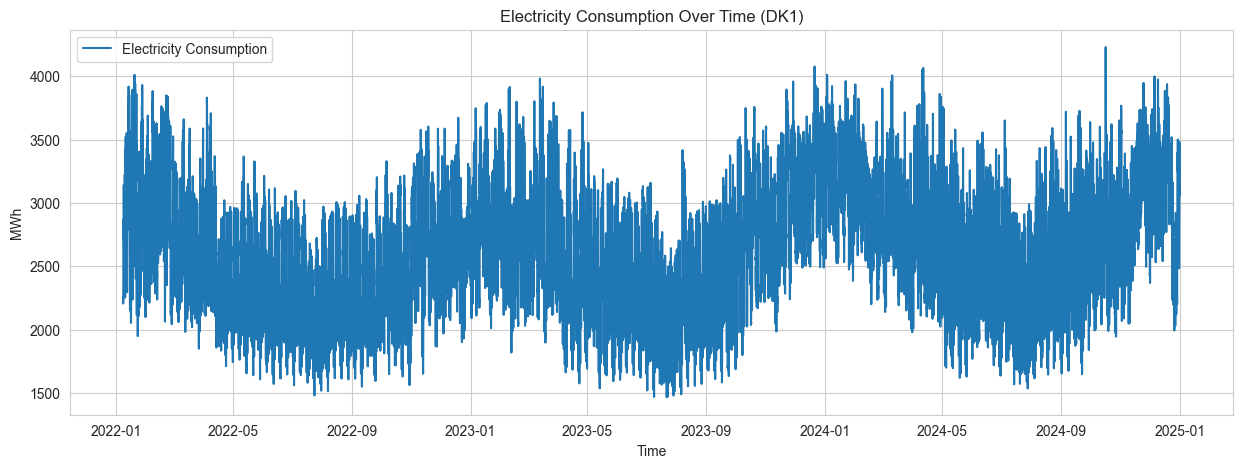

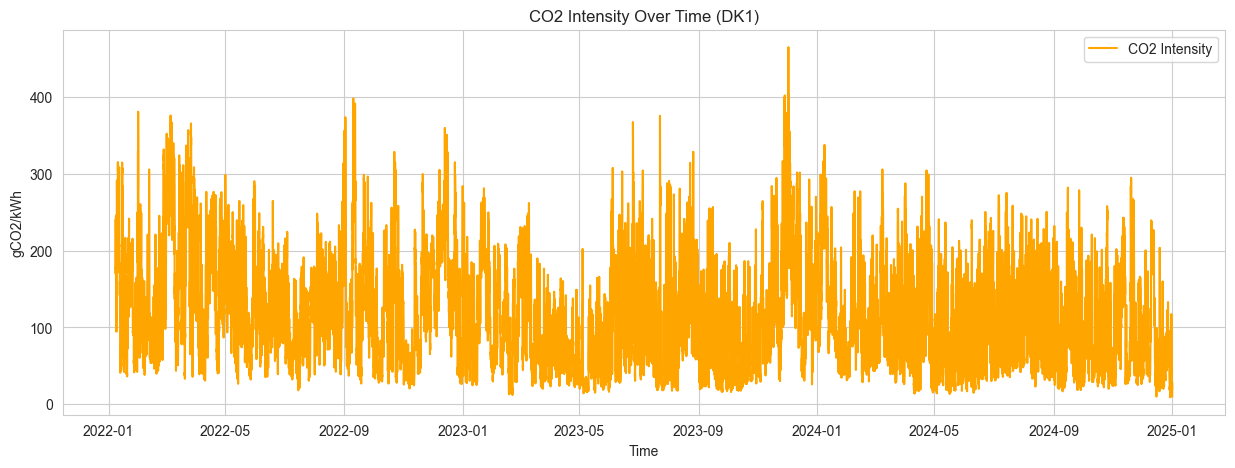

In [27]:
# Time-Series Plots

plt.figure(figsize=(15,5))
plt.plot(eda_df.index, eda_df['GrossConsumptionMWh'], label='Electricity Consumption')
plt.title('Electricity Consumption Over Time (DK1)')
plt.xlabel('Time')
plt.ylabel('MWh')
plt.legend()
plt.show()


plt.figure(figsize=(15,5))
plt.plot(eda_df.index, eda_df['co2_intensity'], color='orange', label='CO2 Intensity')
plt.title('CO2 Intensity Over Time (DK1)')
plt.xlabel('Time')
plt.ylabel('gCO2/kWh')
plt.legend()
plt.show()

The time-series plots provide an overview of the temporal behavior of the two target variables: electricity consumption and CO₂ intensity in DK1.

The electricity consumption series shows clear variation over time, with repeating fluctuations that indicate strong temporal structure. The pattern suggests the presence of seasonality, with generally higher demand during colder periods and lower demand during warmer periods. In addition, there is substantial short-term hourly variation, which indicates that both seasonal effects and recent past values are likely to be important for forecasting.

The CO₂ intensity series also varies considerably over time, but it appears more volatile and irregular than electricity consumption. The presence of frequent peaks suggests that CO₂ intensity is strongly influenced by changes in the electricity generation mix, renewable production, and cross-border exchanges. 

Overall, both target variables exhibit meaningful time-dependent structure. This motivates the inclusion of lagged features and time-based predictors in the forecasting framework.

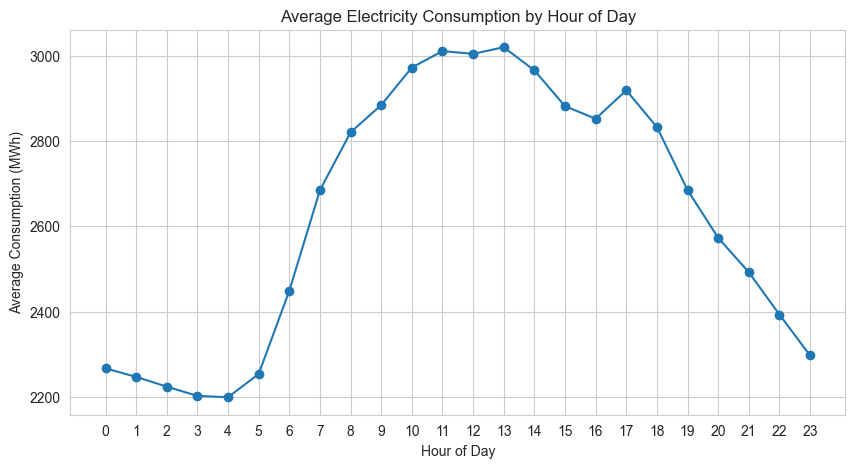

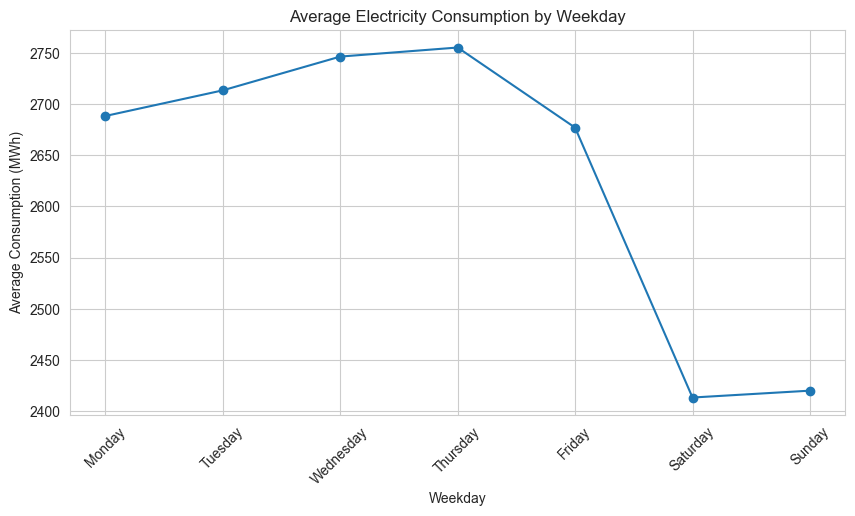

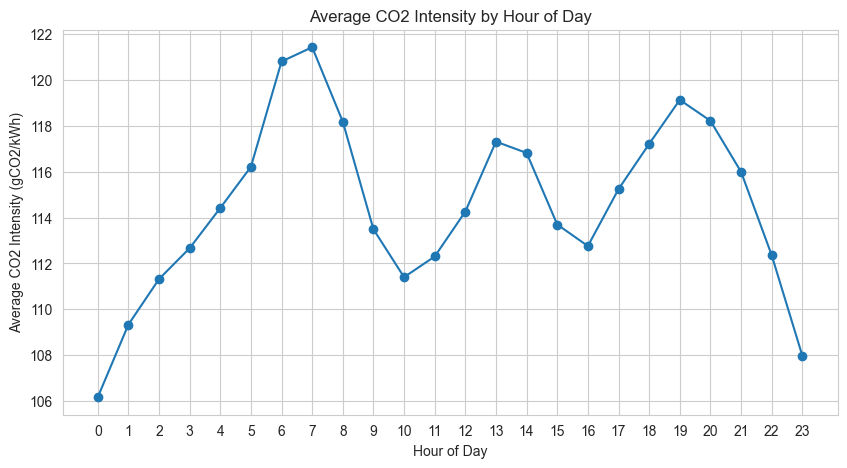

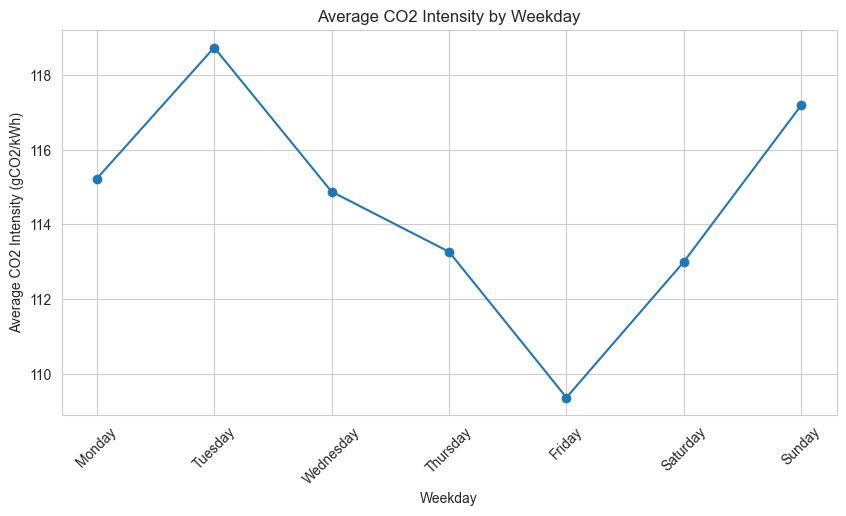

In [28]:

# Daily and Weekly Seasonality
season_df = eda_df.copy()

# time labels for plotting 
season_df['hour'] = season_df.index.hour
season_df['day_of_week'] = season_df.index.dayofweek

# Map weekday numbers to names
weekday_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

season_df['weekday_name'] = season_df['day_of_week'].map(weekday_map)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Electricity consumption by hour 
avg_consumption_by_hour = season_df.groupby('hour')['GrossConsumptionMWh'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_consumption_by_hour.index, avg_consumption_by_hour.values, marker='o')
plt.title('Average Electricity Consumption by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Consumption (MWh)')
plt.xticks(range(0,24))
plt.show()

# Electricity consumption by weekday 
avg_consumption_by_weekday = season_df.groupby('weekday_name')['GrossConsumptionMWh'].mean().reindex(weekday_order)

plt.figure(figsize=(10,5))
plt.plot(avg_consumption_by_weekday.index, avg_consumption_by_weekday.values, marker='o')
plt.title('Average Electricity Consumption by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Consumption (MWh)')
plt.xticks(rotation=45)
plt.show()

#  CO2 intensity by hour 
avg_co2_by_hour = season_df.groupby('hour')['co2_intensity'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_co2_by_hour.index, avg_co2_by_hour.values, marker='o')
plt.title('Average CO2 Intensity by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average CO2 Intensity (gCO2/kWh)')
plt.xticks(range(0,24))
plt.show()

# CO2 intensity by weekday 
avg_co2_by_weekday = season_df.groupby('weekday_name')['co2_intensity'].mean().reindex(weekday_order)

plt.figure(figsize=(10,5))
plt.plot(avg_co2_by_weekday.index, avg_co2_by_weekday.values, marker='o')
plt.title('Average CO2 Intensity by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average CO2 Intensity (gCO2/kWh)')
plt.xticks(rotation=45)
plt.show()

Daily Pattern of Electricity Consumption:

The average electricity consumption by hour of day reveals a clear daily pattern. Consumption is lowest during the night hours, which is consistent with reduced overall activity.

Demand increases during the morning and remains relatively high during daytime hours, before declining again in the evening. This pattern indicates strong intraday seasonality in electricity demand.

The observed daily cycle supports the inclusion of hour-of-day features and lagged variables in the forecasting models.

Weekly Pattern of Electricity Consumption:

The average electricity consumption by weekday reveals a clear weekly pattern. Consumption is generally higher on weekdays and lower during weekends.

This pattern is consistent with differences in human and economic activity across the week. The observed weekday-weekend difference supports the inclusion of day-of-week indicators and weekend flags in the forecasting models.

Daily Pattern of CO₂ Intensity:

The average CO₂ intensity by hour of day shows a daily pattern, although it is less smooth than the consumption pattern. CO₂ intensity tends to vary across the day, with higher values during some morning and evening hours.

These changes may be related to variation in demand, renewable generation, imports, exports, and the overall generation mix. However, the plot should be interpreted as descriptive evidence only and does not identify causal mechanisms.

The observed pattern supports the inclusion of time-based features, while the irregularity of CO₂ intensity suggests that lagged values and system-related predictors may also be relevant.

Weekly Pattern of CO₂ Intensity:

The average CO₂ intensity by weekday shows variation across the week, but the pattern is less regular than the weekday pattern observed for electricity consumption.

Some weekdays show higher average CO₂ intensity than others, while the weekend pattern is not simply lower or higher across both days. This suggests that CO₂ intensity is influenced by a combination of factors, including renewable generation, imports and exports, and broader system conditions.

These results should be interpreted descriptively rather than causally. The weekday pattern alone is not sufficient to explain CO₂ intensity, but it supports the inclusion of calendar-based features as part of the forecasting framework.

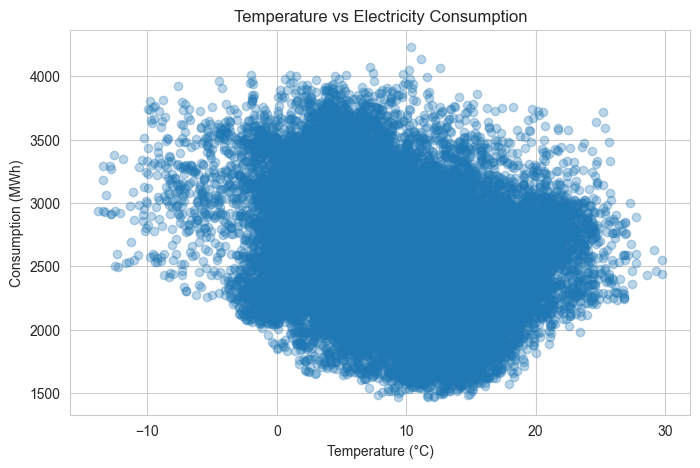

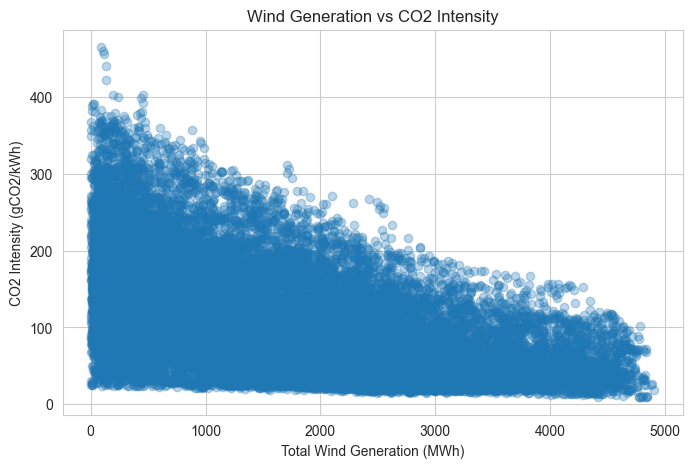

In [29]:

# Relationships

# Temperature vs Electricity Consumption
plt.figure(figsize=(8,5))
plt.scatter(eda_df['temperature'], eda_df['GrossConsumptionMWh'], alpha=0.3)
plt.title('Temperature vs Electricity Consumption')
plt.xlabel('Temperature (°C)')
plt.ylabel('Consumption (MWh)')
plt.show()


# Wind vs CO2 Intensity
plt.figure(figsize=(8,5))
plt.scatter(eda_df['TotalWind_MWh'], eda_df['co2_intensity'], alpha=0.3)
plt.title('Wind Generation vs CO2 Intensity')
plt.xlabel('Total Wind Generation (MWh)')
plt.ylabel('CO2 Intensity (gCO2/kWh)')
plt.show()

Scatter plots were used to explore possible relationships between selected variables.

The relationship between temperature and electricity consumption suggests a nonlinear pattern. Consumption tends to be higher at lower temperatures and lower at moderate temperatures, which is consistent with temperature-sensitive demand. This indicates that temperature may contribute useful information for consumption forecasting.

The relationship between wind generation and CO₂ intensity shows a negative association, where higher wind generation generally coincides with lower CO₂ intensity. This is consistent with the role of wind power in a renewable-heavy electricity system, although the relationship should be interpreted as an association rather than a causal effect.

These exploratory results suggest that nonlinear relationships may exist in the data, but the final importance of these variables must be assessed through the forecasting models and ablation experiments.

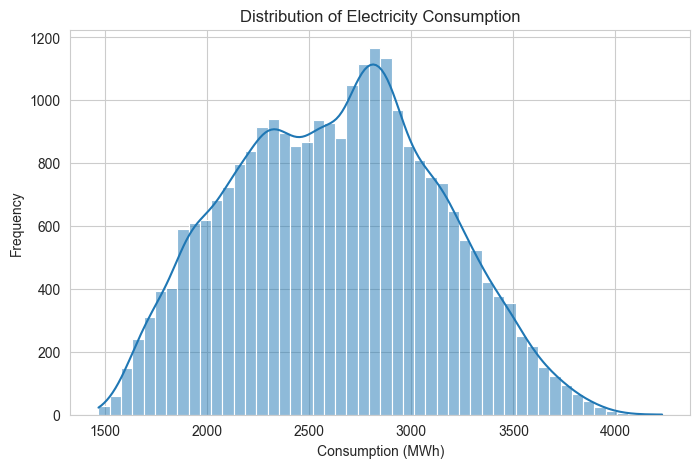

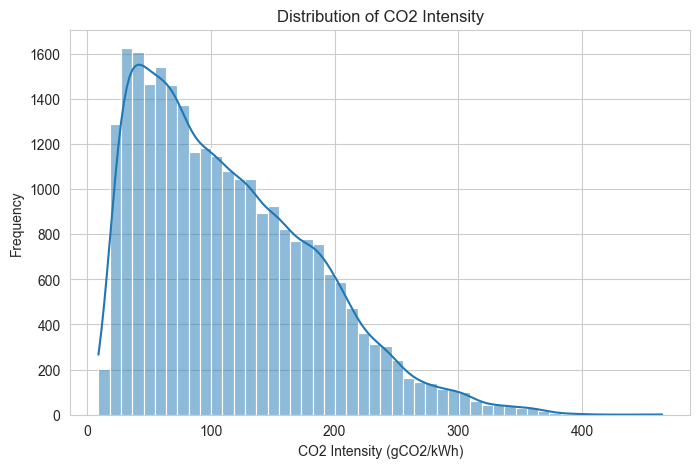

In [30]:

# Distribution Analysis

#  Electricity Consumption Distribution 
plt.figure(figsize=(8,5))
sns.histplot(eda_df['GrossConsumptionMWh'], bins=50, kde=True)
plt.title('Distribution of Electricity Consumption')
plt.xlabel('Consumption (MWh)')
plt.ylabel('Frequency')
plt.show()


#  CO2 Intensity Distribution 
plt.figure(figsize=(8,5))
sns.histplot(eda_df['co2_intensity'], bins=50, kde=True)
plt.title('Distribution of CO2 Intensity')
plt.xlabel('CO2 Intensity (gCO2/kWh)')
plt.ylabel('Frequency')
plt.show()

Distribution Analysis of Target Variables:

The distribution of electricity consumption appears relatively concentrated, with most observations lying within a moderate range and fewer extreme values. This suggests that electricity consumption is comparatively stable over the study period.

CO₂ intensity is more right-skewed, with many observations at lower values and a long tail toward higher values. This indicates the presence of occasional high CO₂ intensity periods.

These distributional differences suggest that CO₂ intensity may be more affected by irregular system conditions than electricity consumption. However, model suitability should be evaluated based on forecasting performance and residual errors rather than the target distribution alone.

In [31]:
# Top 5 highest and lowest values

print("Top 5 highest Electricity Consumption:")
display(eda_df[['GrossConsumptionMWh']].nlargest(5, 'GrossConsumptionMWh'))

print("Top 5 lowest Electricity Consumption:")
display(eda_df[['GrossConsumptionMWh']].nsmallest(5, 'GrossConsumptionMWh'))

print("Top 5 highest CO2 Intensity:")
display(eda_df[['co2_intensity']].nlargest(5, 'co2_intensity'))

print("Top 5 lowest CO2 Intensity:")
display(eda_df[['co2_intensity']].nsmallest(5, 'co2_intensity'))

Top 5 highest Electricity Consumption:


,GrossConsumptionMWh
datetime_dk,
2024-10-16 12:00:00+02:00,4228.427907
2024-10-16 13:00:00+02:00,4136.442502
2023-12-21 13:00:00+01:00,4076.008471
2024-04-11 13:00:00+02:00,4065.245537
2024-04-10 14:00:00+02:00,4050.871215


Top 5 lowest Electricity Consumption:


,GrossConsumptionMWh
datetime_dk,
2023-07-22 05:00:00+02:00,1466.739560
2023-07-09 05:00:00+02:00,1468.841761
2023-07-23 02:00:00+02:00,1469.704509
2023-07-23 03:00:00+02:00,1475.543979
2023-07-09 04:00:00+02:00,1476.333187


Top 5 highest CO2 Intensity:


,co2_intensity
datetime_dk,
2023-12-02 13:00:00+01:00,464.750000
2023-12-02 12:00:00+01:00,460.083333
2023-12-02 11:00:00+01:00,455.833333
2023-12-02 10:00:00+01:00,440.416667
2023-12-02 14:00:00+01:00,421.500000


Top 5 lowest CO2 Intensity:


,co2_intensity
datetime_dk,
2024-12-29 19:00:00+01:00,9.000000
2024-12-29 20:00:00+01:00,9.000000
2024-12-29 21:00:00+01:00,9.000000
2024-12-30 01:00:00+01:00,9.500000
2025-01-01 00:00:00+01:00,9.666667


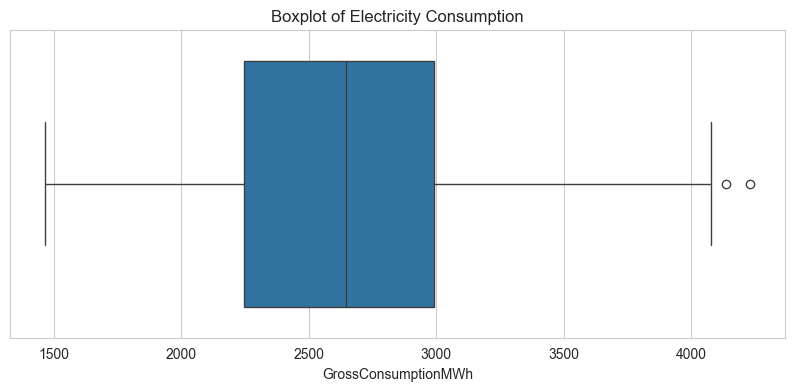

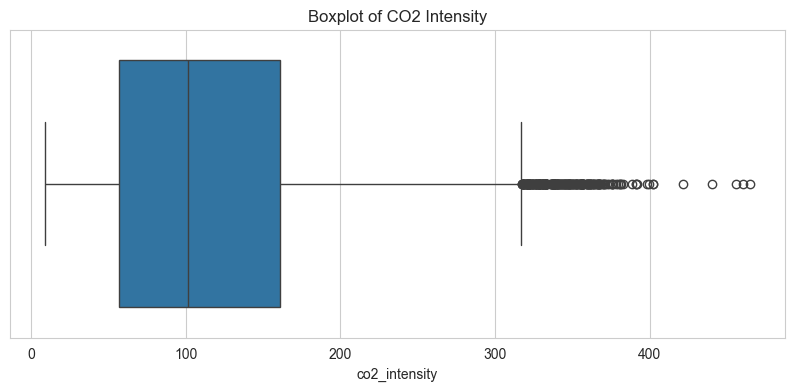

In [32]:
plt.figure(figsize=(10,4))
sns.boxplot(x=eda_df['GrossConsumptionMWh'])
plt.title('Boxplot of Electricity Consumption')
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x=eda_df['co2_intensity'])
plt.title('Boxplot of CO2 Intensity')
plt.show()

In [33]:
# IQR Outlier Check 

def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print("Lower bound:", round(lower, 2))
    print("Upper bound:", round(upper, 2))
    print("Number of outliers:", len(outliers))

    return outliers

# Apply on your variables
out_c = iqr_outliers(eda_df, 'GrossConsumptionMWh')
out_co2 = iqr_outliers(eda_df, 'co2_intensity')


GrossConsumptionMWh
Lower bound: 1132.78
Upper bound: 4102.89
Number of outliers: 2

co2_intensity
Lower bound: -99.79
Upper bound: 317.21
Number of outliers: 238


Outlier Analysis Using IQR Method:

An interquartile range (IQR) based approach was used to identify extreme values in electricity consumption and CO₂ intensity.

For electricity consumption, the lower and upper bounds were estimated at approximately 1132.78 MWh and 4102.89 MWh, respectively. Only two observations were identified as outliers, indicating that electricity consumption is relatively stable and exhibits limited extreme deviations.

In contrast, CO₂ intensity shows a significantly larger number of outliers. The upper bound was estimated at approximately 317.21 gCO₂/kWh, with 238 observations exceeding this threshold. This is also evident in the boxplot, where a large number of points appear beyond the upper whisker.

The high number of outliers in CO₂ intensity reflects the inherent variability of the electricity generation mix. Periods of low renewable generation, particularly low wind output, combined with increased reliance on fossil-based production or imports, can lead to sharp increases in CO₂ intensity.

Importantly, these extreme values are not treated as data errors. Instead, they represent realistic system conditions and are therefore retained for subsequent modelling. Removing such observations would reduce the realism of the forecasting task and potentially bias model evaluation.

In [34]:
print(eda_df.columns.tolist())

['datetime_utc', 'CentralPowerMWh', 'LocalPowerMWh', 'CommercialPowerMWh', 'LocalPowerSelfConMWh', 'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh', 'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh', 'HydroPowerMWh', 'SolarPowerLt10kW_MWh', 'SolarPowerGe10Lt40kW_MWh', 'SolarPowerGe40kW_MWh', 'SolarPowerSelfConMWh', 'UnknownProdMWh', 'ExchangeNO_MWh', 'ExchangeSE_MWh', 'ExchangeGE_MWh', 'ExchangeNL_MWh', 'ExchangeGB_MWh', 'ExchangeGreatBelt_MWh', 'GrossConsumptionMWh', 'GridLossTransmissionMWh', 'GridLossInterconnectorsMWh', 'GridLossDistributionMWh', 'PowerToHeatMWh', 'WindOffshore_MWh', 'WindOnshore_MWh', 'TotalWind_MWh', 'TotalSolar_MWh', 'TotalRenewables_MWh', 'TotalConventional_MWh', 'NetExchange_MWh', 'TotalImports_MWh', 'TotalExports_MWh', 'TotalProduction_MWh', 'co2_intensity', 'temperature', 'wind_speed', 'solar_radiation', 'hour', 'day_of_week', 'month', 'is_weekend', 'season_spring', 'season_summer', 'season_winter', 'co2_lag_1', 'co2_lag_24', 'co2_lag_168', 'cons_lag_1', 

## Forecasting Setup and Treatment of Weather Variables

A one-hour-ahead forecasting setup is adopted, where the objective is to predict electricity consumption and CO₂ intensity at time \(t+1\) using information available at time \(t\).

To reduce data leakage, contemporaneous system variables such as production, renewable generation, imports, exports, and net exchange are excluded from the model inputs. These variables are included only through lagged values, representing information from the previously observed system state.

Lagged values of electricity consumption and CO₂ intensity are included to capture short-term persistence, daily seasonality, and weekly temporal structure. Calendar variables such as hour of day, day of week, month, weekend indicator, and season are retained because they are known in advance.

Weather variables, including temperature, wind speed, and solar radiation, are included under the assumption that short-term weather forecasts are available. In the empirical implementation, observed weather values are used as proxies for forecasted weather inputs. Therefore, the reported model performance should be interpreted as an idealized or upper-bound forecasting scenario rather than a fully operational real-time forecast.

In [35]:
# Make sure final_df is an independent copy
final_df = final_df.copy()

# Create Lagged Production Features
final_df.loc[:, 'wind_lag1'] = final_df['TotalWind_MWh'].shift(1)
final_df.loc[:, 'solar_lag1'] = final_df['TotalSolar_MWh'].shift(1)
final_df.loc[:, 'renewables_lag1'] = final_df['TotalRenewables_MWh'].shift(1)
final_df.loc[:,'conventional_lag1'] = final_df['TotalConventional_MWh'].shift(1)
final_df.loc[:, 'production_lag1'] = final_df['TotalProduction_MWh'].shift(1)
final_df.loc[:, 'imports_lag1'] = final_df['TotalImports_MWh'].shift(1)
final_df.loc[:, 'exports_lag1'] = final_df['TotalExports_MWh'].shift(1)
final_df.loc[:, 'netexchange_lag1'] = final_df['NetExchange_MWh'].shift(1)

In [36]:
#check
print(final_df[['wind_lag1', 'solar_lag1', 'renewables_lag1','conventional_lag1',
                'production_lag1', 'imports_lag1',
                'exports_lag1', 'netexchange_lag1']].head())

       wind_lag1  solar_lag1  renewables_lag1  conventional_lag1  \
168          NaN         NaN              NaN                NaN   
169  1514.506265    0.020231      1517.366409        1769.893677   
170  1591.529154    0.019312      1594.388571        1754.047443   
171  2047.264690    0.020917      2050.111242        1630.835297   
172  2061.370262    0.019702      2064.214709        1443.523017   

     production_lag1  imports_lag1  exports_lag1  netexchange_lag1  
168              NaN           NaN           NaN               NaN  
169      3287.260086       706.557     1738.8374        -1032.2804  
170      3348.436014       715.928     1847.1060        -1131.1780  
171      3680.946539       699.532     2174.6998        -1475.1678  
172      3507.737726       689.025     1980.8440        -1291.8190  


In [37]:
#removing missing values
final_df = final_df.dropna().reset_index(drop=True)
print(final_df.shape)

(26135, 62)


In [38]:
final_df.head()

,datetime_utc,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,...,cons_lag_24,cons_lag_168,wind_lag1,solar_lag1,renewables_lag1,conventional_lag1,production_lag1,imports_lag1,exports_lag1,netexchange_lag1
0,2022-01-08 01:00:00+00:00,1454.415809,193.725505,92.993926,12.912203,87.361597,432.442842,6.431664,1065.293051,2.840105,...,2652.991549,2147.758315,1514.506265,0.020231,1517.366409,1769.893677,3287.260086,706.557,1738.8374,-1032.2804
1,2022-01-08 02:00:00+00:00,1326.106185,196.600129,92.946838,15.182145,112.488667,752.824081,8.316151,1173.635791,2.825635,...,2624.932058,2023.389045,1591.529154,0.019312,1594.388571,1754.047443,3348.436014,715.928,1847.1060,-1131.1780
2,2022-01-08 03:00:00+00:00,1136.644153,194.351411,94.859170,17.668283,118.254828,681.685467,8.750022,1252.679945,2.824745,...,2518.178217,2050.223766,2047.264690,0.020917,2050.111242,1630.835297,3680.946539,699.532,2174.6998,-1475.1678
3,2022-01-08 04:00:00+00:00,1394.893524,215.025167,94.561262,18.315674,76.308818,626.237402,10.647061,1372.721304,2.828848,...,2812.590459,2065.765754,2061.370262,0.019702,2064.214709,1443.523017,3507.737726,689.025,1980.8440,-1291.8190
4,2022-01-08 05:00:00+00:00,1316.947659,309.029459,96.831960,17.206028,184.835216,969.969357,11.325410,1435.496508,2.858046,...,3110.981584,2084.435142,2085.914585,0.019528,2088.762961,1722.795627,3811.558588,303.870,1854.0366,-1550.1666


In [39]:
#FINAL FEATURE CHECK
print(final_df.dtypes)

datetime_utc            datetime64[us, UTC]
CentralPowerMWh                     float64
LocalPowerMWh                       float64
CommercialPowerMWh                  float64
LocalPowerSelfConMWh                float64
                               ...         
conventional_lag1                   float64
production_lag1                     float64
imports_lag1                        float64
exports_lag1                        float64
netexchange_lag1                    float64
Length: 62, dtype: object


In [40]:
#SAVE THE DATA SET
final_df.to_csv("final_dataset_full_features.csv", index=False)
print("Full dataset saved successfully!")


Full dataset saved successfully!


The final dataset includes all engineered features. Data leakage is prevented during the modelling stage by selecting only lagged and available predictors.

In [41]:
#Creating Model-Ready Dataset (Leakage-Free)
# Create a copy for modelling
model_df = final_df.copy()

In [42]:
# Remove Leakage Variables

leakage_cols = [
    'CentralPowerMWh', 'LocalPowerMWh', 'CommercialPowerMWh',
    'LocalPowerSelfConMWh',

    'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh',
    'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh',

    'HydroPowerMWh',

    'SolarPowerLt10kW_MWh', 'SolarPowerGe10Lt40kW_MWh',
    'SolarPowerGe40kW_MWh', 'SolarPowerSelfConMWh',

    'UnknownProdMWh',

    'ExchangeNO_MWh', 'ExchangeSE_MWh', 'ExchangeGE_MWh',
    'ExchangeNL_MWh', 'ExchangeGB_MWh', 'ExchangeGreatBelt_MWh',

    'GridLossTransmissionMWh', 'GridLossInterconnectorsMWh',
    'GridLossDistributionMWh',

    'PowerToHeatMWh',

    'WindOffshore_MWh', 'WindOnshore_MWh',

    'TotalWind_MWh', 'TotalSolar_MWh',
    'TotalRenewables_MWh', 'TotalConventional_MWh',
    'NetExchange_MWh', 'TotalImports_MWh',
    'TotalExports_MWh', 'TotalProduction_MWh'
]

model_df = model_df.drop(columns=leakage_cols)

In [43]:
#final check
print(model_df.shape)
print(model_df.columns.tolist())

(26135, 28)
['datetime_utc', 'GrossConsumptionMWh', 'co2_intensity', 'temperature', 'wind_speed', 'solar_radiation', 'datetime_dk', 'hour', 'day_of_week', 'month', 'is_weekend', 'season_spring', 'season_summer', 'season_winter', 'co2_lag_1', 'co2_lag_24', 'co2_lag_168', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168', 'wind_lag1', 'solar_lag1', 'renewables_lag1', 'conventional_lag1', 'production_lag1', 'imports_lag1', 'exports_lag1', 'netexchange_lag1']


A model-ready dataset was constructed by removing variables that could introduce look-ahead bias. Contemporaneous production, renewable generation, and exchange variables were excluded, while lagged system variables, lagged target variables, weather variables, and time-based features were retained.

Because observed weather variables are used as proxies for short-term weather forecasts, the setup should be interpreted as a leakage-controlled but idealized one-hour-ahead forecasting framework.

In [120]:
model_df.to_csv("final_dataset_model_ready.csv", index=False)
print("Model-ready dataset saved successfully!")

Model-ready dataset saved successfully!
